In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder
warnings.filterwarnings('ignore')
warnings.simplefilter("ignore")

In [3]:
df = pd.read_csv('../data/bank_clean.csv')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343.0,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45.0,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270.0,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476.0,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184.0,no,no,unknown,5,may,673,2,-1,0,unknown,yes


Посмотрим на распределение целевого признака

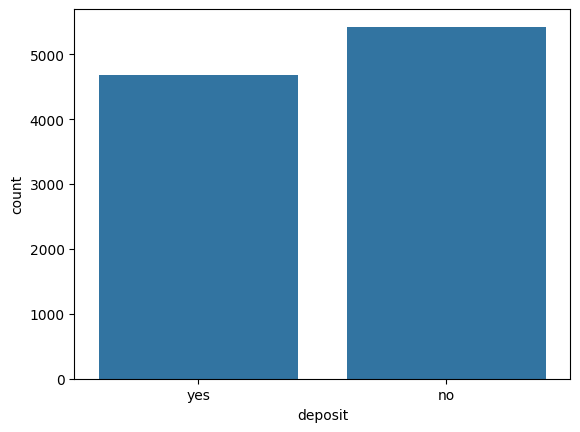

In [4]:
df['deposit'].value_counts(normalize=True)

sns.countplot(x='deposit', data=df)
plt.show()

Классы немного не сбалансированны

In [5]:
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,10105,10105,10105,10105,10105,10105,10105,10105,10105,10105
unique,11,3,3,2,2,2,3,12,4,2
top,management,married,secondary,no,no,no,cellular,may,unknown,no
freq,2315,5715,5517,9939,5243,8712,7283,2617,7570,5424


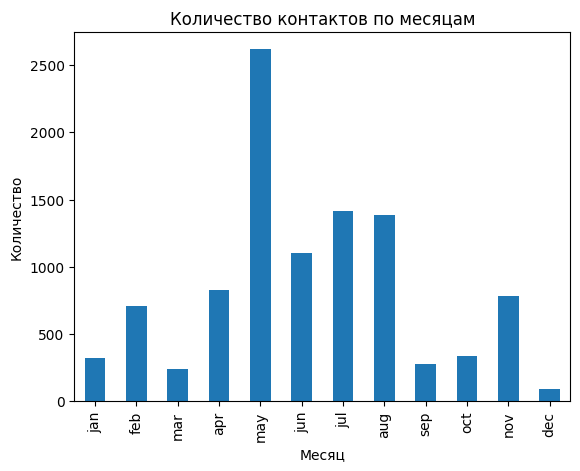

In [6]:
#Отсортируем месяца в нужном порядке для удобства
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
#Построим график распределения контактов по месяцам
df['month'].value_counts().reindex(month_order).plot(kind='bar')

plt.title('Количество контактов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество')
plt.show()

Самый объемный месяц - май, так же можно выделить более продуктивный сезон - лето

In [7]:
#Сгруппируем целевой признак по результатам маркетинговых кампаний
df.groupby('poutcome')['deposit'].value_counts().unstack()

deposit,no,yes
poutcome,,
failure,562,547
other,216,265
success,84,861
unknown,4562,3008


<Axes: xlabel='poutcome', ylabel='count'>

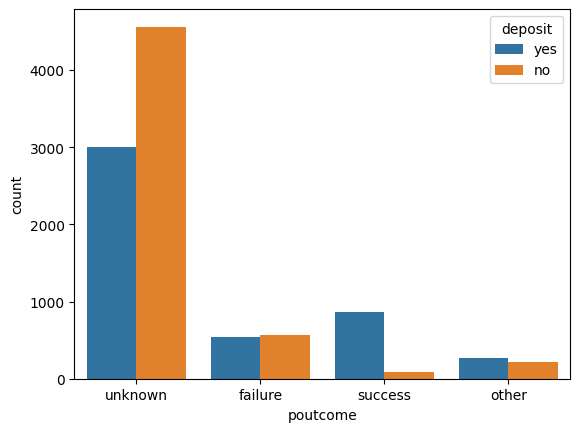

In [8]:
sns.countplot(
    data=df,
    x='poutcome',
    hue='deposit',
    order=df['poutcome'].value_counts().index
)

In [9]:
#Возьмем уникальные значения месяца
months = df['month'].unique()

max_ratio = 0
worst_month = None

#Пройдемся циклом по каждому месяцу
for month in months:
    month_data = df[df['month'] == month]

    #Посчитаем отказы
    refusals = (month_data['deposit'] == 'no').sum()
    total = len(month_data)

    #Вычислим долю отказов
    ratio = refusals / total

    #Определим месяц
    if ratio > max_ratio:
        max_ratio = ratio
        worst_month = month

worst_month

'may'

Больше всего доля отказов в мае, но май, как было видно, так же самый продуктивный месяц

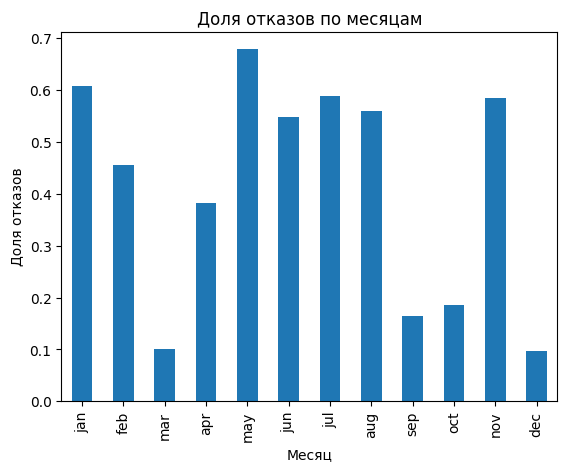

In [10]:
refusal_rate = (df['deposit'] == 'no').groupby(df['month']).mean()

refusal_rate = refusal_rate.reindex(month_order)

refusal_rate.plot(kind='bar')

plt.title('Доля отказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Доля отказов')

plt.show()

Из графика видно, что доля отказов в мае не сильно превышает долю отказов в ноябре и январе, а так же в летний период

In [11]:
#Разобьем возраст по группам
bins = [0, 30, 40, 50, 60, 100]
labels = ['<30', '30-40', '40-50', '50-60', '60+']

#Инициализируем признак возрастной группы
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

#Смотрим на распределение
df['age_group'].value_counts()

age_group
30-40    3961
40-50    2382
50-60    1654
<30      1455
60+       653
Name: count, dtype: int64

Количество клиентов преобладает в возрастной группе 30-40 лет

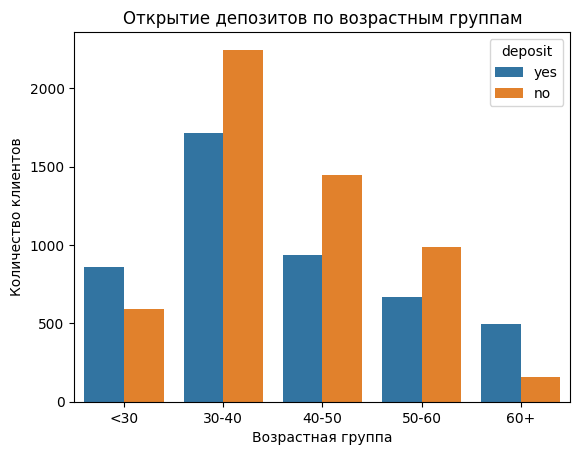

In [12]:
sns.countplot(data=df, x='age_group', hue='deposit')

plt.title('Открытие депозитов по возрастным группам')
plt.xlabel('Возрастная группа')
plt.ylabel('Количество клиентов')

plt.show()

Больше склонны к открытию депозитов клиенты в возрасте до 30 лет и старше 60, доля отказов выше у клиентов от 30 до 60 лет

In [13]:
#Цифровое распределение открытия депозитов по возрастным группам
df.groupby('age_group')['deposit'].value_counts(normalize=True).unstack()

deposit,no,yes
age_group,,
<30,0.408247,0.591753
30-40,0.566776,0.433224
40-50,0.606213,0.393787
50-60,0.594921,0.405079
60+,0.240429,0.759571


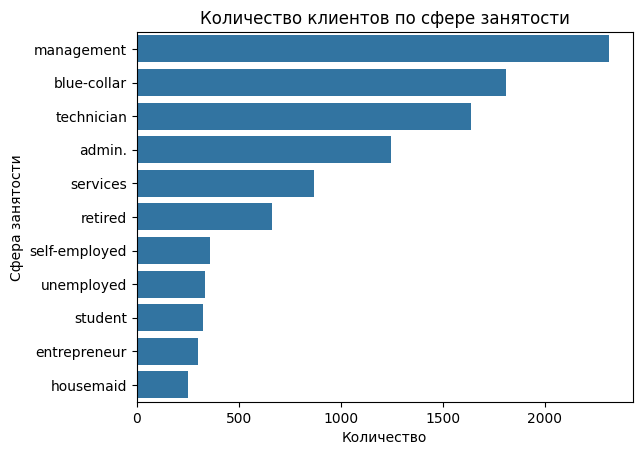

In [14]:
sns.countplot(data=df, y='job', order=df['job'].value_counts().index)

plt.title('Количество клиентов по сфере занятости')
plt.xlabel('Количество')
plt.ylabel('Сфера занятости')

plt.show()

Самая вовлеченная сфера - менеджмент

In [ ]:
#Посмотрим на числовое распределение
df.groupby('job')['deposit'].value_counts(normalize=True).unstack()

deposit,no,yes
job,,
admin.,0.539326,0.460674
blue-collar,0.639181,0.360819
entrepreneur,0.630000,0.370000
housemaid,0.607143,0.392857
management,0.509719,0.490281
retired,0.348416,0.651584
self-employed,0.550279,0.449721
services,0.602535,0.397465
student,0.248466,0.751534


Пенсионеры, студенты и безработные чаще открывают депозиты

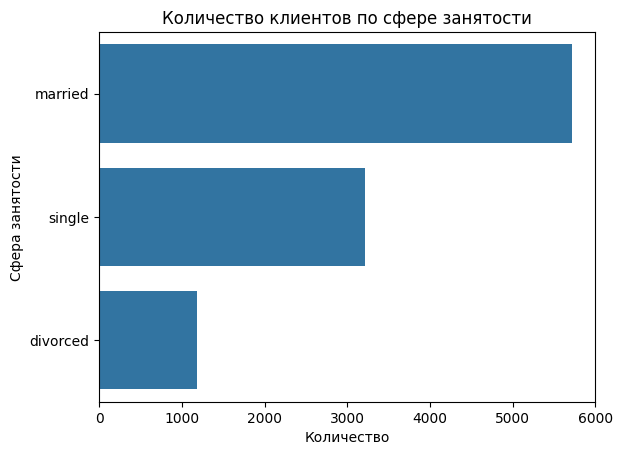

In [16]:
sns.countplot(data=df, y='marital', order=df['marital'].value_counts().index)

plt.title('Количество клиентов по сфере занятости')
plt.xlabel('Количество')
plt.ylabel('Сфера занятости')

plt.show()

Подавляющее большинство открывших депозиты - женатые люди

In [17]:
df.groupby('marital')['deposit'].value_counts(normalize=True).unstack()

deposit,no,yes
marital,,
divorced,0.530161,0.469839
married,0.577953,0.422047
single,0.465920,0.534080


Но у одиноких больше доля открытия депозитов

Составим тепловую карту

In [18]:
df_yes = df[df['deposit'] == 'yes']
df_no = df[df['deposit'] == 'no']

In [19]:
pivot_yes = pd.pivot_table(
    df_yes,
    index='education',
    columns='marital',
    aggfunc='size'
)

pivot_no = pd.pivot_table(
    df_no,
    index='education',
    columns='marital',
    aggfunc='size'
)

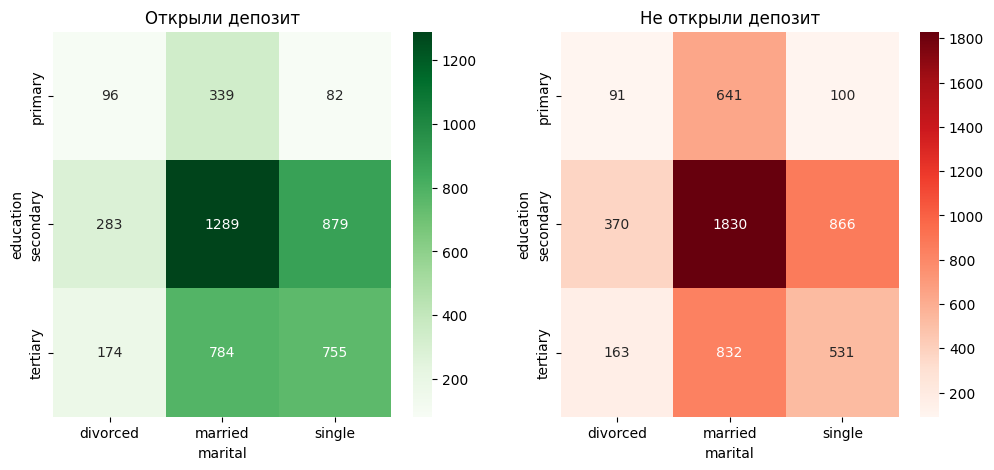

In [20]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(pivot_yes, annot=True, fmt='g', cmap='Greens')
plt.title('Открыли депозит')

plt.subplot(1,2,2)
sns.heatmap(pivot_no, annot=True, fmt='g', cmap='Reds')
plt.title('Не открыли депозит')

plt.show()